In [1]:
import os

REPO = "https://github.com/minhbuibhm/rag_chatbot_asm.git"
WORK_DIR = "/kaggle/working/rag_chatbot_asm"

# Clone hoặc pull nếu đã có
if not os.path.exists(WORK_DIR):
    os.system(f"git clone {REPO} {WORK_DIR}")
else:
    os.system(f"cd {WORK_DIR} && git pull")

# Chuyển working directory → relative paths hoạt động đúng
os.chdir(WORK_DIR)
print(f"CWD: {os.getcwd()}")

Cloning into '/kaggle/working/rag_chatbot_asm'...


CWD: /kaggle/working/rag_chatbot_asm


Updating files: 100% (16457/16457), done.


In [2]:
!pip install -q langchain-community langchain-google-genai langchain-core faiss-cpu scikit-learn pandas numpy tqdm
!pip install --upgrade langchain
!pip install --upgrade langchain-text-splitters
!pip install --upgrade tqdm
!pip install langchain_huggingface
!pip install openpyxl
!pip install matplotlib
!pip install sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.3/508.3 kB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 5.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pand

In [3]:
!pip install faiss-cpu
from langchain_community.vectorstores import FAISS

In [4]:
import pandas as pd
import os
import json

# === Configuration - Local paths ===
DOCUMENTS_PATH = "Dataset/export_1"
RES_PATH = "RES.xlsx"
RESULTS_DIR = "report/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# === Load RES dataset ===
df = pd.read_excel(RES_PATH)
# Only keep relevant columns 
df = df[["Câu Hỏi", "Trả lời"]].dropna()
df.to_csv("res.csv", index=False)

print(f"Total Q&A pairs: {len(df)}")
print(f"Documents path: {DOCUMENTS_PATH}")
print(f"Total documents: {len([f for f in os.listdir(DOCUMENTS_PATH) if f.endswith('.txt')])}")
print(f"\nSample question: {df.iloc[0]['Câu Hỏi'][:100]}...")
print(f"Sample answer: {df.iloc[0]['Trả lời'][:100]}...")

Total Q&A pairs: 2745
Documents path: Dataset/export_1
Total documents: 16439

Sample question: Soft OTP là hình thức xác thực thế nào, gồm những loại nào và phần mềm Soft OTP cần tuân thủ những y...
Sample answer: Căn cứ tại điểm d khoản 3 Điều 11 Thông tư 50/2024/TT-NHNN quy định về Soft OTP là hình thức xác nhậ...


## Phase 2: Data Exploration & Understanding
### 2.1 Legal Documents Corpus Analysis

=== CORPUS STATISTICS ===
  total_documents: 16439
  total_characters: 329117214
  length_min: 737
  length_max: 798241
  length_mean: 20020.5
  length_median: 12271.0
  length_std: 29447.9
  length_q25: 6667.5
  length_q75: 22312.5

  Document types:
    Quyết định (QĐ): 8829
    Khác: 5214
    UBND: 1455
    Thông tư (TT): 388
    Nghị định (NĐ): 308
    Chính phủ (CP): 115
    Chỉ thị (CT): 79
    Thông báo (TB): 39
    Nghị quyết (NQ): 12


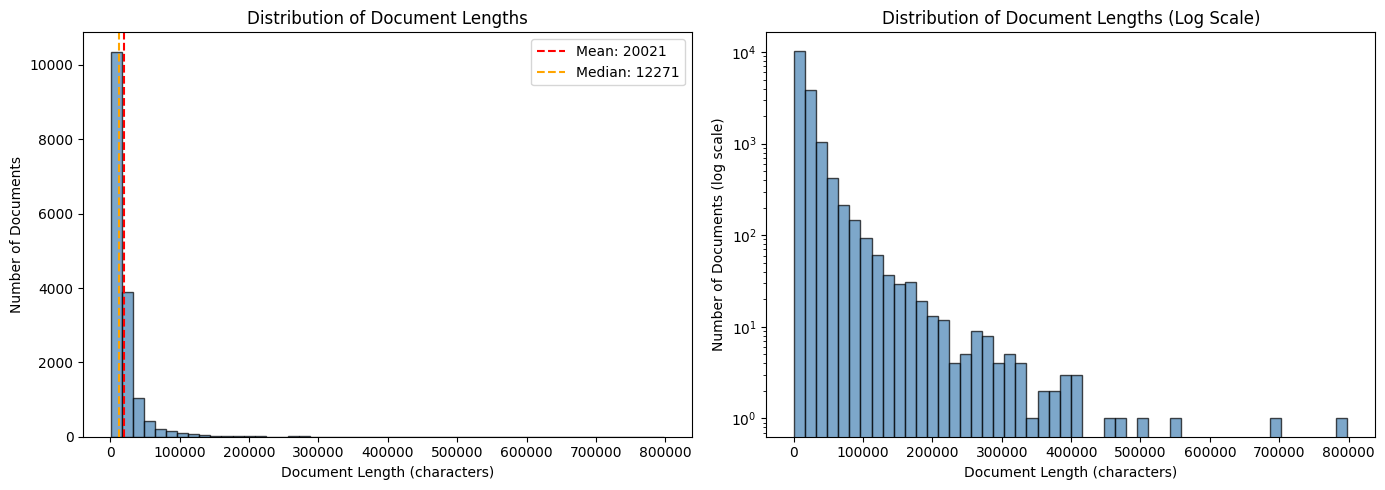

Saved: report/results/doc_length_distribution.png


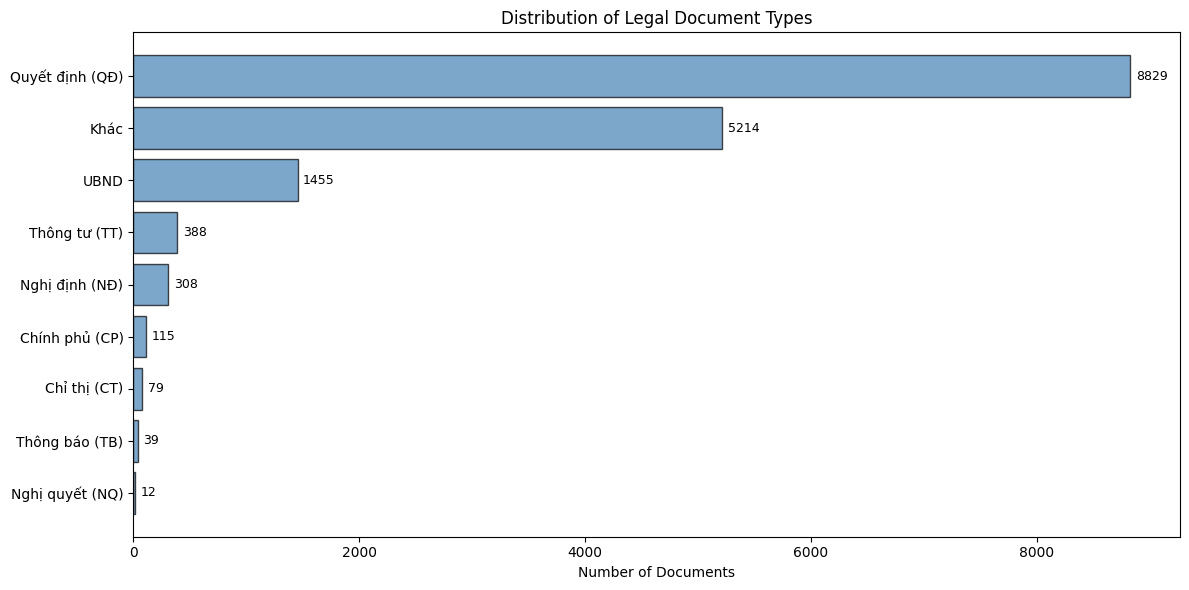

Saved: report/results/doc_type_distribution.png


In [5]:
# ============================================================
# Phase 2.1: Legal Documents Corpus Analysis
# ============================================================
import os
import json
import re
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

DOCUMENTS_PATH = "Dataset/export_1"
RESULTS_DIR = "report/results"

# --- Load all documents and compute stats ---
doc_lengths = []
doc_names = []
all_text = []

for filename in sorted(os.listdir(DOCUMENTS_PATH)):
    if filename.endswith(".txt"):
        filepath = os.path.join(DOCUMENTS_PATH, filename)
        with open(filepath, 'r', encoding='utf-8') as f:
            content = f.read()
        doc_lengths.append(len(content))
        doc_names.append(filename)
        all_text.append(content.lower())

doc_lengths = np.array(doc_lengths)

corpus_stats = {
    "total_documents": len(doc_lengths),
    "total_characters": int(doc_lengths.sum()),
    "length_min": int(doc_lengths.min()),
    "length_max": int(doc_lengths.max()),
    "length_mean": round(float(doc_lengths.mean()), 1),
    "length_median": round(float(np.median(doc_lengths)), 1),
    "length_std": round(float(doc_lengths.std()), 1),
    "length_q25": round(float(np.percentile(doc_lengths, 25)), 1),
    "length_q75": round(float(np.percentile(doc_lengths, 75)), 1),
}

# --- Classify document types by filename prefix ---
type_patterns = {
    "Thông tư (TT)": r"^\d*-?TT",
    "Nghị định (NĐ)": r"^\d*-?NĐ|NĐ-CP",
    "Quyết định (QĐ)": r"^\d*-?QĐ|QĐ-",
    "Nghị quyết (NQ)": r"^\d*-?NQ",
    "Chỉ thị (CT)": r"^\d*-?CT",
    "Luật": r"^luật|_luật",
    "Thông báo (TB)": r"^\d*-?TB",
    "Công văn (CV)": r"^\d*-?CV",
    "Chính phủ (CP)": r"^\d*-?CP",
    "UBND": r"UBND",
}

doc_types = Counter()
for name in doc_names:
    classified = False
    for label, pattern in type_patterns.items():
        if re.search(pattern, name, re.IGNORECASE):
            doc_types[label] += 1
            classified = True
            break
    if not classified:
        doc_types["Khác"] += 1

corpus_stats["doc_types"] = dict(doc_types.most_common())

# --- Save stats ---
with open(os.path.join(RESULTS_DIR, "corpus_stats.json"), "w", encoding="utf-8") as f:
    json.dump(corpus_stats, f, ensure_ascii=False, indent=2)

print("=== CORPUS STATISTICS ===")
for k, v in corpus_stats.items():
    if k != "doc_types":
        print(f"  {k}: {v}")
print(f"\n  Document types:")
for dtype, count in doc_types.most_common():
    print(f"    {dtype}: {count}")

# --- Plot 1: Document length distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(doc_lengths, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Document Length (characters)')
axes[0].set_ylabel('Number of Documents')
axes[0].set_title('Distribution of Document Lengths')
axes[0].axvline(doc_lengths.mean(), color='red', linestyle='--', label=f'Mean: {doc_lengths.mean():.0f}')
axes[0].axvline(np.median(doc_lengths), color='orange', linestyle='--', label=f'Median: {np.median(doc_lengths):.0f}')
axes[0].legend()

# Log scale for better visibility
axes[1].hist(doc_lengths, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Document Length (characters)')
axes[1].set_ylabel('Number of Documents (log scale)')
axes[1].set_title('Distribution of Document Lengths (Log Scale)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "doc_length_distribution.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {RESULTS_DIR}/doc_length_distribution.png")

# --- Plot 2: Document type distribution ---
types_sorted = doc_types.most_common()
labels = [t[0] for t in types_sorted]
counts = [t[1] for t in types_sorted]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(labels[::-1], counts[::-1], color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Number of Documents')
ax.set_title('Distribution of Legal Document Types')
for bar, count in zip(bars, counts[::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2, str(count), va='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "doc_type_distribution.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {RESULTS_DIR}/doc_type_distribution.png")

### 2.2 RES Dataset (Q&A Pairs) Analysis

=== RES DATASET STATISTICS ===
  Total Q&A pairs: 2745

  Questions:
    length_char_min: 41
    length_char_max: 322
    length_char_mean: 141.0
    length_char_median: 137.0
    length_word_min: 11
    length_word_max: 71
    length_word_mean: 30.6

  Answers:
    length_char_min: 62
    length_char_max: 9858
    length_char_mean: 1619.3
    length_char_median: 1426.0
    length_word_min: 11
    length_word_max: 2084
    length_word_mean: 350.9


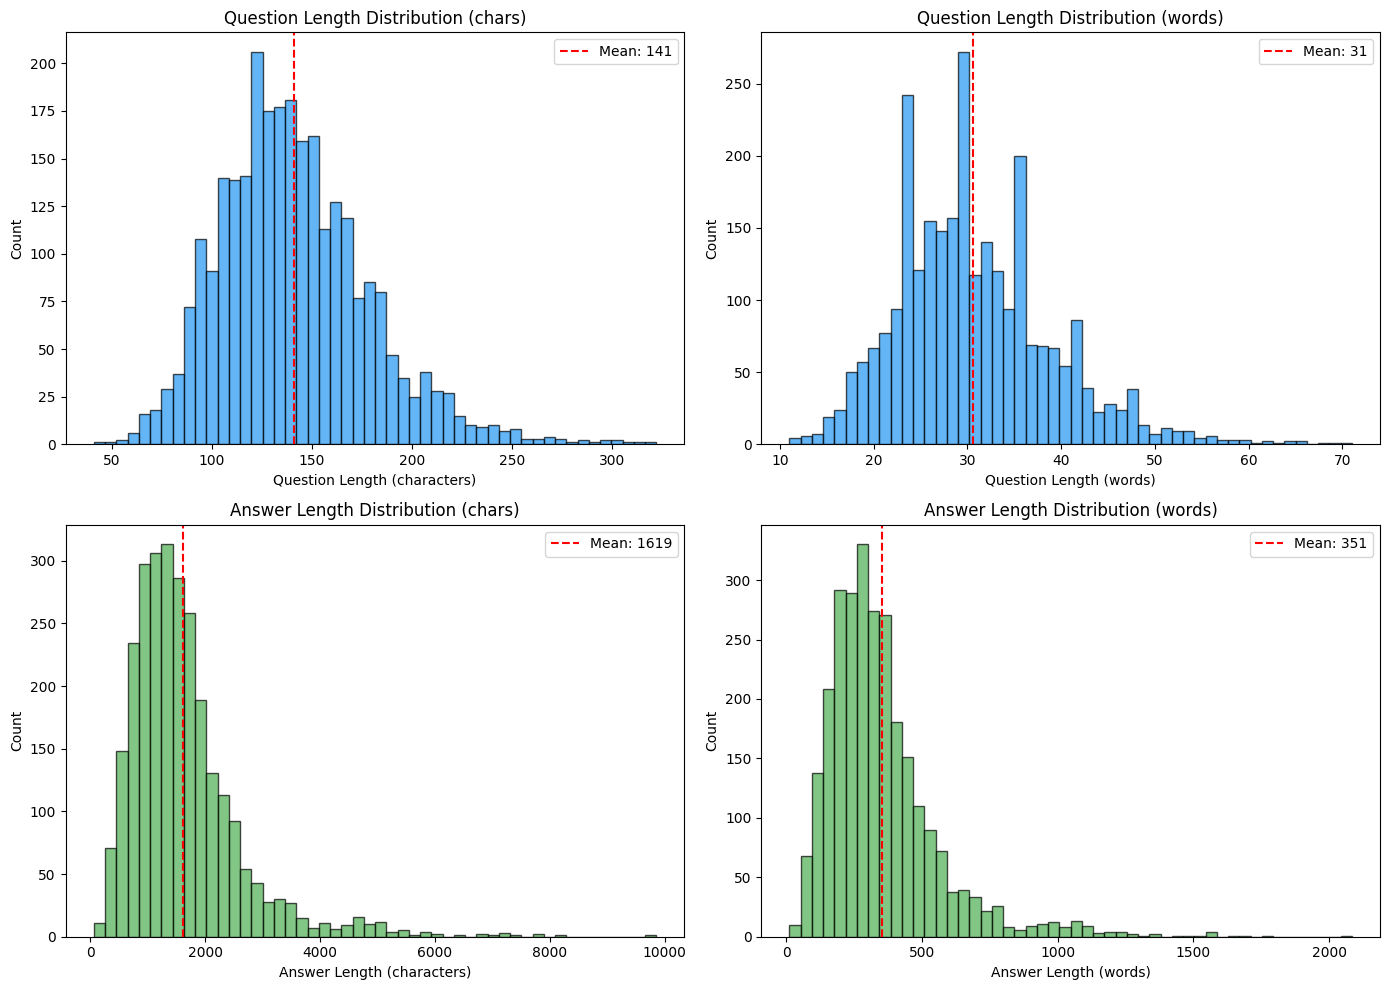

Saved: report/results/qa_length_distribution.png

Saved: report/results/sample_qa_pairs.csv

--- Q0 ---
  Q: Soft OTP là hình thức xác thực thế nào, gồm những loại nào và phần mềm Soft OTP cần tuân thủ những yêu cầu cụ thể gì the...
  A: Căn cứ tại điểm d khoản 3 Điều 11 Thông tư 50/2024/TT-NHNN quy định về Soft OTP là hình thức xác nhận thông qua mã OTP đ...

--- Q304 ---
  Q: Nếu các bên thỏa thuận bù trừ công nợ và đẩy nhanh việc thanh toán, thì người vay vốn nước ngoài cần xử lý, điều chỉnh b...
  A: Theo điểm a khoản 4 Điều 7 Thông tư 08/2023/TT-NHNN quy định về phương án sử dụng vốn vay nước ngoài như sau:Phương án s...

--- Q609 ---
  Q: Theo Luật Các tổ chức tín dụng 2024, những nghĩa vụ và quyền chính của các nhà quản trị và điều hành tại tổ chức tín dụn...
  A: Căn cứ theo Điều 48 Luật Các tổ chức tín dụng 2024, quyền và nghĩa vụ của người quản lý, người điều hành tổ chức tín dụn...

--- Q914 ---
  Q: Theo Thông tư 29/2024/TT-NHNN, những điều kiện cụ thể để cá nhân, hộ gia đì

In [6]:
# ============================================================
# Phase 2.2: RES Dataset (Q&A Pairs) Analysis
# ============================================================
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

RESULTS_DIR = "report/results"
df = pd.read_csv("res.csv")

# --- Compute stats ---
q_lengths_char = df["Câu Hỏi"].str.len()
a_lengths_char = df["Trả lời"].str.len()
q_lengths_word = df["Câu Hỏi"].str.split().str.len()
a_lengths_word = df["Trả lời"].str.split().str.len()

res_stats = {
    "total_qa_pairs": len(df),
    "question": {
        "length_char_min": int(q_lengths_char.min()),
        "length_char_max": int(q_lengths_char.max()),
        "length_char_mean": round(float(q_lengths_char.mean()), 1),
        "length_char_median": round(float(q_lengths_char.median()), 1),
        "length_word_min": int(q_lengths_word.min()),
        "length_word_max": int(q_lengths_word.max()),
        "length_word_mean": round(float(q_lengths_word.mean()), 1),
    },
    "answer": {
        "length_char_min": int(a_lengths_char.min()),
        "length_char_max": int(a_lengths_char.max()),
        "length_char_mean": round(float(a_lengths_char.mean()), 1),
        "length_char_median": round(float(a_lengths_char.median()), 1),
        "length_word_min": int(a_lengths_word.min()),
        "length_word_max": int(a_lengths_word.max()),
        "length_word_mean": round(float(a_lengths_word.mean()), 1),
    }
}

with open(f"{RESULTS_DIR}/res_stats.json", "w", encoding="utf-8") as f:
    json.dump(res_stats, f, ensure_ascii=False, indent=2)

print("=== RES DATASET STATISTICS ===")
print(f"  Total Q&A pairs: {res_stats['total_qa_pairs']}")
print(f"\n  Questions:")
for k, v in res_stats['question'].items():
    print(f"    {k}: {v}")
print(f"\n  Answers:")
for k, v in res_stats['answer'].items():
    print(f"    {k}: {v}")

# --- Plot: Q&A length distributions ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(q_lengths_char, bins=50, color='#2196F3', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Question Length (characters)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Question Length Distribution (chars)')
axes[0, 0].axvline(q_lengths_char.mean(), color='red', linestyle='--', label=f'Mean: {q_lengths_char.mean():.0f}')
axes[0, 0].legend()

axes[0, 1].hist(q_lengths_word, bins=50, color='#2196F3', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Question Length (words)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Question Length Distribution (words)')
axes[0, 1].axvline(q_lengths_word.mean(), color='red', linestyle='--', label=f'Mean: {q_lengths_word.mean():.0f}')
axes[0, 1].legend()

axes[1, 0].hist(a_lengths_char, bins=50, color='#4CAF50', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Answer Length (characters)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Answer Length Distribution (chars)')
axes[1, 0].axvline(a_lengths_char.mean(), color='red', linestyle='--', label=f'Mean: {a_lengths_char.mean():.0f}')
axes[1, 0].legend()

axes[1, 1].hist(a_lengths_word, bins=50, color='#4CAF50', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Answer Length (words)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Answer Length Distribution (words)')
axes[1, 1].axvline(a_lengths_word.mean(), color='red', linestyle='--', label=f'Mean: {a_lengths_word.mean():.0f}')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/qa_length_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {RESULTS_DIR}/qa_length_distribution.png")

# --- Save sample Q&A pairs (diverse selection) ---
sample_indices = np.linspace(0, len(df)-1, 10, dtype=int)
sample_df = df.iloc[sample_indices][["Câu Hỏi", "Trả lời"]].copy()
sample_df.columns = ["Question", "Answer"]
sample_df["Answer_Truncated"] = sample_df["Answer"].str[:200] + "..."
sample_df.to_csv(f"{RESULTS_DIR}/sample_qa_pairs.csv", index=False, encoding="utf-8-sig")
print(f"\nSaved: {RESULTS_DIR}/sample_qa_pairs.csv")

# Display samples
for i, row in sample_df.iterrows():
    print(f"\n--- Q{i} ---")
    print(f"  Q: {row['Question'][:120]}...")
    print(f"  A: {row['Answer_Truncated'][:120]}...")

### 2.3 Chunking Analysis & Top Keywords

Loading documents for chunking analysis...
=== CHUNK STATISTICS (Baseline Config) ===
  total_chunks: 188226
  total_documents: 16439
  chunks_per_doc_mean: 11.45
  chunks_per_doc_median: 7.0
  chunks_per_doc_max: 452
  chunk_length_min: 20
  chunk_length_max: 2000
  chunk_length_mean: 1756.3
  chunk_length_median: 1893.0


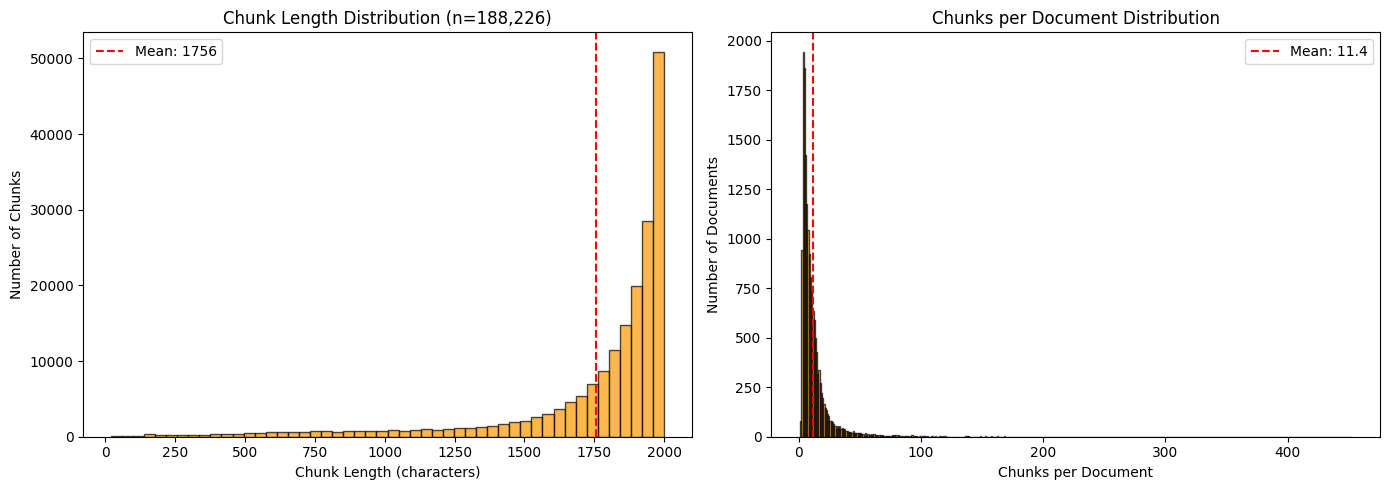

Saved: report/results/chunk_length_distribution.png

Computing top keywords...


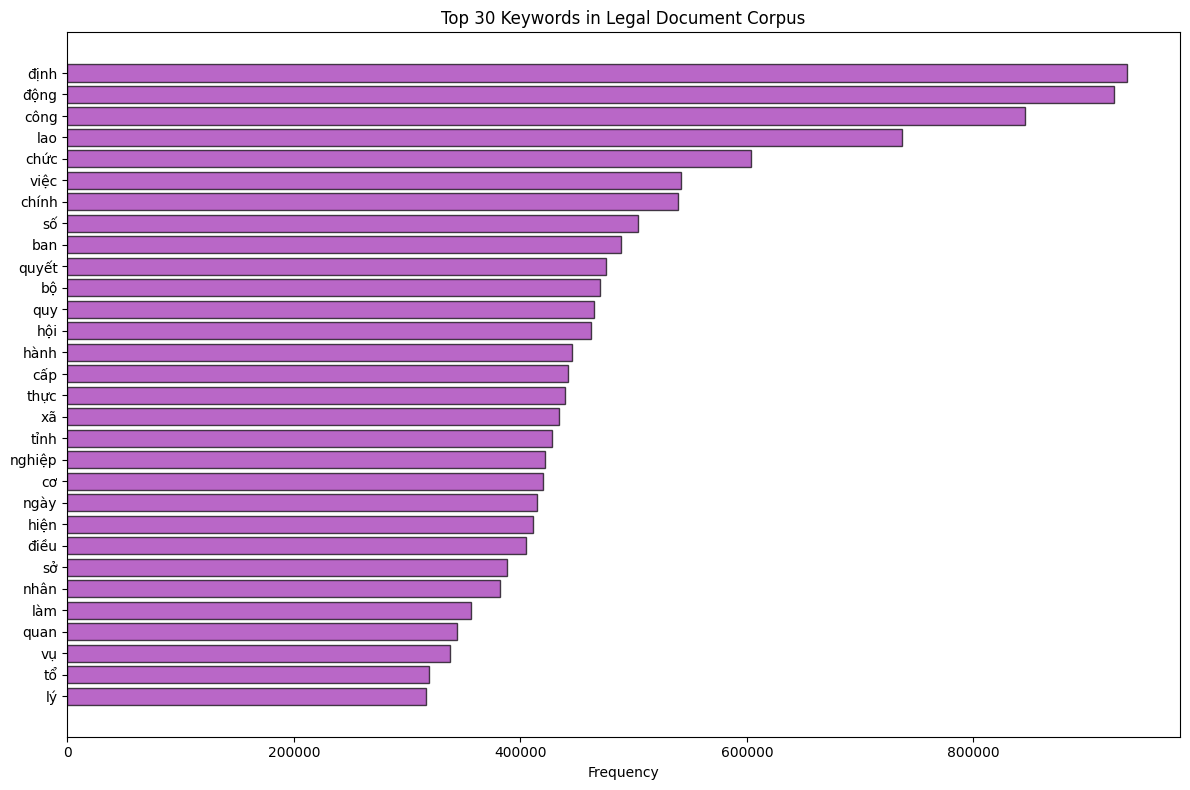

Saved: report/results/top_keywords.png


In [7]:
# ============================================================
# Phase 2.3: Chunking Analysis & Top Keywords
# ============================================================
import os
import json
import re
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from langchain_text_splitters import RecursiveCharacterTextSplitter

DOCUMENTS_PATH = "Dataset/export_1"
RESULTS_DIR = "report/results"

# --- Load documents (reuse if already loaded) ---
print("Loading documents for chunking analysis...")
raw_contents = []
for filename in sorted(os.listdir(DOCUMENTS_PATH)):
    if filename.endswith(".txt"):
        with open(os.path.join(DOCUMENTS_PATH, filename), 'r', encoding='utf-8') as f:
            raw_contents.append(f.read())

# --- Baseline chunking config ---
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=2000,
    chunk_overlap=50,
    length_function=len
)

all_chunks = []
chunks_per_doc = []
for content in raw_contents:
    chunks = text_splitter.split_text(content)
    all_chunks.extend(chunks)
    chunks_per_doc.append(len(chunks))

chunk_lengths = np.array([len(c) for c in all_chunks])
chunks_per_doc = np.array(chunks_per_doc)

chunk_stats = {
    "chunking_config": {
        "chunk_size": 2000,
        "chunk_overlap": 50,
        "method": "RecursiveCharacterTextSplitter"
    },
    "total_chunks": len(all_chunks),
    "total_documents": len(raw_contents),
    "chunks_per_doc_mean": round(float(chunks_per_doc.mean()), 2),
    "chunks_per_doc_median": round(float(np.median(chunks_per_doc)), 1),
    "chunks_per_doc_max": int(chunks_per_doc.max()),
    "chunk_length_min": int(chunk_lengths.min()),
    "chunk_length_max": int(chunk_lengths.max()),
    "chunk_length_mean": round(float(chunk_lengths.mean()), 1),
    "chunk_length_median": round(float(np.median(chunk_lengths)), 1),
}

with open(f"{RESULTS_DIR}/chunk_stats.json", "w", encoding="utf-8") as f:
    json.dump(chunk_stats, f, ensure_ascii=False, indent=2)

print("=== CHUNK STATISTICS (Baseline Config) ===")
for k, v in chunk_stats.items():
    if k != "chunking_config":
        print(f"  {k}: {v}")

# --- Plot: Chunk length distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(chunk_lengths, bins=50, color='#FF9800', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Chunk Length (characters)')
axes[0].set_ylabel('Number of Chunks')
axes[0].set_title(f'Chunk Length Distribution (n={len(all_chunks):,})')
axes[0].axvline(chunk_lengths.mean(), color='red', linestyle='--', label=f'Mean: {chunk_lengths.mean():.0f}')
axes[0].legend()

axes[1].hist(chunks_per_doc, bins=range(0, int(chunks_per_doc.max())+2), color='#FF9800', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Chunks per Document')
axes[1].set_ylabel('Number of Documents')
axes[1].set_title('Chunks per Document Distribution')
axes[1].axvline(chunks_per_doc.mean(), color='red', linestyle='--', label=f'Mean: {chunks_per_doc.mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/chunk_length_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {RESULTS_DIR}/chunk_length_distribution.png")

# --- Top Keywords (from all documents) ---
print("\nComputing top keywords...")

# Vietnamese stopwords (common ones)
vn_stopwords = set("và của là trong có được cho này với các không một những để theo về từ đã khi tại như trên đến hoặc nhưng cũng do nếu sẽ vì còn hay người năm đó bị phải ra đi qua tuy rằng".split())

word_counter = Counter()
for content in raw_contents:
    text = content.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    words = [w for w in text.split() if len(w) > 1 and w not in vn_stopwords and not w.isdigit()]
    word_counter.update(words)

top_words = word_counter.most_common(30)

fig, ax = plt.subplots(figsize=(12, 8))
words = [w[0] for w in top_words[::-1]]
freqs = [w[1] for w in top_words[::-1]]
ax.barh(words, freqs, color='#9C27B0', edgecolor='black', alpha=0.7)
ax.set_xlabel('Frequency')
ax.set_title('Top 30 Keywords in Legal Document Corpus')
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/top_keywords.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {RESULTS_DIR}/top_keywords.png")

# Save top keywords
with open(f"{RESULTS_DIR}/top_keywords.json", "w", encoding="utf-8") as f:
    json.dump(top_words, f, ensure_ascii=False, indent=2)

In [ ]:
import os
from tqdm import tqdm
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import TextLoader
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings

# === Configuration ===
DOCUMENTS_PATH = "Dataset/export_1"
EMBEDDING_MODEL = "keepitreal/vietnamese-sbert"
BATCH_SIZE = 1024
OUTPUT_DIR = "faiss_db"

# === Kaggle pre-built paths ===
KAGGLE_FAISS = "/kaggle/input/llm-rag-asm/faiss_db"
KAGGLE_CACHE = "/kaggle/input/llm-rag-asm/embeddings_cache.pkl"

# === Skip if FAISS already available ===
if os.path.exists(KAGGLE_FAISS) or os.path.exists(OUTPUT_DIR):
    _src = KAGGLE_FAISS if os.path.exists(KAGGLE_FAISS) else OUTPUT_DIR
    print(f"FAISS found at '{_src}' — skipping doc loading & chunking.")
    texts = None
else:
    def load_text_documents(path):
      documents = []
      for filename in os.listdir(path):
          if filename.endswith(".txt"):
              file_path = os.path.join(path, filename)
              loader = TextLoader(file_path, encoding='utf-8')
              raw_docs = loader.load()
              for doc in raw_docs:
                  content = doc.page_content.replace("", " ").lower().strip()
                  doc.page_content = content
                  documents.append(doc)
      return documents

    print("Loading text documents...")
    raw_documents = load_text_documents(DOCUMENTS_PATH)
    print(f"Total documents found: {len(raw_documents)}")

    subset_idx = len(raw_documents)
    raw_documents = raw_documents[:subset_idx]
    print(f"Documents selected for embedding: {len(raw_documents)}")

    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=2000,
        chunk_overlap=50,
        length_function=len
    )

    texts = []
    for doc in tqdm(raw_documents, desc="Splitting documents into chunks"):
        chunks = text_splitter.split_documents([doc])
        texts.extend(chunks)

    print(f"Total chunks created: {len(texts)}")


Loading text documents...
Total documents found: 16439
Documents selected for embedding: 16439


Splitting documents into chunks: 100%|██████████| 16439/16439 [02:08<00:00, 128.20it/s]

Total chunks created: 176504


In [9]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# === Initialize embeddings (always needed for later cells) ===
print(f"Loading embedding model: {EMBEDDING_MODEL}")
embeddings = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    model_kwargs={"device": "cuda"}
)

# === Skip FAISS build if already available ===
if os.path.exists(KAGGLE_FAISS) or os.path.exists(OUTPUT_DIR):
    print("FAISS already available — skipping build.")
else:
    vectorstore = None
    for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="Embedding and adding to FAISS"):
        batch = texts[i:i + BATCH_SIZE]
        batch_embeddings = embeddings.embed_documents([t.page_content for t in batch])
        if vectorstore is None:
            vectorstore = FAISS.from_texts(
                [t.page_content for t in batch],
                embeddings
            )
        else:
            vectorstore.add_texts(
                [t.page_content for t in batch],
                embedding=batch_embeddings
            )

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    vectorstore.save_local(OUTPUT_DIR)
    print(f"FAISS vectorstore saved to '{OUTPUT_DIR}'")


/tmp/ipykernel_24/60268628.py:6: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(


Loading embedding model: keepitreal/vietnamese-sbert


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding and adding to FAISS: 100%|██████████| 173/173 [1:50:20<00:00, 38.27s/it]


FAISS vectorstore successfully saved to 'faiss_db'


In [10]:
import pickle

EMBEDDINGS_CACHE = "embeddings_cache.pkl"

# === Skip if FAISS already available ===
if os.path.exists(KAGGLE_FAISS) or os.path.exists(OUTPUT_DIR):
    # Copy from Kaggle input to working dir if needed
    if os.path.exists(KAGGLE_FAISS) and not os.path.exists(OUTPUT_DIR):
        import shutil
        shutil.copytree(KAGGLE_FAISS, OUTPUT_DIR)
        print(f"Copied FAISS from '{KAGGLE_FAISS}' to '{OUTPUT_DIR}'")
    if os.path.exists(KAGGLE_CACHE) and not os.path.exists(EMBEDDINGS_CACHE):
        import shutil
        shutil.copy2(KAGGLE_CACHE, EMBEDDINGS_CACHE)
        print(f"Copied embeddings cache from '{KAGGLE_CACHE}'")
    print("FAISS + cache ready — skipping build.")
else:
    vectorstore = None

    if os.path.exists(EMBEDDINGS_CACHE):
        print(f"Loading cached embeddings from '{EMBEDDINGS_CACHE}'...")
        with open(EMBEDDINGS_CACHE, "rb") as f:
            all_texts, all_embeddings = pickle.load(f)
        print(f"Loaded {len(all_texts)} cached embeddings.")
    elif os.path.exists(KAGGLE_CACHE):
        print(f"Loading cached embeddings from '{KAGGLE_CACHE}'...")
        with open(KAGGLE_CACHE, "rb") as f:
            all_texts, all_embeddings = pickle.load(f)
        print(f"Loaded {len(all_texts)} cached embeddings.")
    else:
        print("Computing embeddings...")
        all_texts = []
        all_embeddings = []
        for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="Embedding chunks"):
            batch = texts[i:i + BATCH_SIZE]
            batch_texts = [t.page_content for t in batch]
            batch_embeddings = embeddings.embed_documents(batch_texts)
            all_texts.extend(batch_texts)
            all_embeddings.extend(batch_embeddings)
        with open(EMBEDDINGS_CACHE, "wb") as f:
            pickle.dump((all_texts, all_embeddings), f)
        print(f"Embeddings cached to '{EMBEDDINGS_CACHE}'.")

    print("Building FAISS index...")
    for i in tqdm(range(0, len(all_texts), BATCH_SIZE), desc="Adding to FAISS"):
        batch_texts = all_texts[i:i + BATCH_SIZE]
        batch_embs = all_embeddings[i:i + BATCH_SIZE]
        if vectorstore is None:
            vectorstore = FAISS.from_embeddings(
                list(zip(batch_texts, batch_embs)),
                embeddings
            )
        else:
            vectorstore.add_embeddings(
                list(zip(batch_texts, batch_embs))
            )


Computing embeddings...


Embedding chunks: 100%|██████████| 173/173 [55:08<00:00, 19.12s/it]


Embeddings cached to 'embeddings_cache.pkl'.
Building FAISS index...


Adding to FAISS: 100%|██████████| 173/173 [00:13<00:00, 13.17it/s]


In [11]:
import numpy as np
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings

# === Configuration ===
EMBEDDING_MODEL = "keepitreal/vietnamese-sbert"
VECTORSTORE_PATH = "faiss_db"

# === Load FAISS vectorstore ===
print("Loading FAISS vectorstore...")
embeddings = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    model_kwargs={"device": "cuda"}
)

vectorstore = FAISS.load_local(
    VECTORSTORE_PATH,
    embeddings,
    allow_dangerous_deserialization=True
)
print("FAISS vectorstore loaded successfully.")

# === Display a sample record ===
keys = list(vectorstore.docstore._dict.keys())
if not keys:
    raise ValueError("The FAISS docstore is empty. No records found.")

first_key = keys[0]
record = vectorstore.docstore._dict[first_key]

print("\n--- First Record ---")
print(f"ID: {first_key}")
print(f"Content (truncated): {record.page_content[:200]}...")
print(f"Metadata: {record.metadata}")

# === Retrieve the corresponding vector ===
index_id = 0  # first vector
vector = vectorstore.index.reconstruct(index_id)

print("\n--- Corresponding Vector ---")
print(f"Vector size: {len(vector)}")
print(f"First 5 values: {vector[:5]}")


Loading FAISS vectorstore...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: keepitreal/vietnamese-sbert
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FAISS vectorstore loaded successfully.

--- First Record ---
ID: d61b35a5-8de9-4d44-9b59-1dc0a5a032b7
Content (truncated): ủy  ban nhân dân  tỉnh bắc kạn   -------  cộng  hòa xã hội chủ nghĩa việt nam   độc lập - tự do - hạnh phúc    ---------------  số: 168/kh-ubnd  bắc  kạn, ngày 26 tháng 3 năm 2021      kế hoạch  đào t...
Metadata: {}

--- Corresponding Vector ---
Vector size: 768
First 5 values: [ 0.18359205 -0.10133886  0.09018134 -0.18972129 -0.0084635 ]


In [12]:
import os
import re
import pandas as pd
import numpy as np
from tqdm import tqdm
from collections import Counter

from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_huggingface import HuggingFacePipeline
from langchain_google_genai import ChatGoogleGenerativeAI
from sklearn.metrics.pairwise import cosine_similarity

# ==================== LOAD DATA ====================
df = pd.read_csv("res.csv")
df = df.head(30)
print(f"Total number of questions: {len(df)}")

# # ==================== LOAD FAISS + EMBEDDINGS ====================
# embedding_model_name = "keepitreal/vietnamese-sbert"
# embeddings = HuggingFaceEmbeddings(
#     model_name=embedding_model_name,
#     model_kwargs={"device": "cpu"}  # or "cuda"
# )

vectorstore = FAISS.load_local(
    "faiss_db",
    embeddings=embeddings,
    allow_dangerous_deserialization=True
)

# ==================== LOAD LLM ====================
llm = HuggingFacePipeline.from_model_id(
    model_id="Qwen/Qwen1.5-1.8B", #Choose your model
    task="text-generation",
    device=0,  # GPU 0
    pipeline_kwargs={"max_new_tokens": 256, "temperature": 0.01, "do_sample": True}
)

# ==================== HELPER FUNCTIONS ====================
def normalize_text(text: str) -> str:
    text = str(text).lower().replace("\n", " ").strip()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text

def rag_query(question: str, k: int = 5) -> str:
    docs = vectorstore.similarity_search(question, k=k)
    context_texts = []
    for doc in docs:
        if hasattr(doc, "page_content"):
            context_texts.append(doc.page_content)
        elif isinstance(doc, dict) and "page_content" in doc:
            context_texts.append(doc["page_content"])
        else:
            context_texts.append(str(doc))
    context = "\n".join(context_texts)

    prompt = f"""
Bạn là một trợ lý thông minh. Trả lời câu hỏi dựa trên ngữ cảnh sau.
Nếu không đủ thông tin, hãy nói rõ điều đó, không được tự bịa đặt.

Ngữ cảnh:
{context}

Câu hỏi: {question}
Trả lời ngắn gọn và chính xác nhất có thể:
"""

    output = llm.generate([prompt],  max_new_tokens=256)
    generated_text = output.generations[0][0].text
    print(generated_text)
    return generated_text

def cosine_similarity_score(pred: str, true: str, emb_model) -> float:
    if not pred or not true:
        return 0.0
    pred_vec = emb_model.embed_query(pred)
    true_vec = emb_model.embed_query(true)
    return float(cosine_similarity([pred_vec], [true_vec])[0][0])

def jaccard_similarity(pred: str, true: str) -> float:
    pred_words = set(normalize_text(pred).split())
    true_words = set(normalize_text(true).split())
    return len(pred_words & true_words) / len(pred_words | true_words) if pred_words and true_words else 0.0

def token_overlap_score(pred: str, true: str) -> float:
    pred_words = normalize_text(pred).split()
    true_words = normalize_text(true).split()
    if not true_words:
        return 0.0
    return sum((Counter(pred_words) & Counter(true_words)).values()) / len(true_words)

def bleu_score_simple(pred: str, true: str) -> float:
    pred_words = normalize_text(pred).split()
    true_words = normalize_text(true).split()
    if not pred_words or not true_words:
        return 0.0
    overlap = sum((Counter(pred_words) & Counter(true_words)).values())
    precision = overlap / len(pred_words)
    bp = 1.0 if len(pred_words) >= len(true_words) else np.exp(1 - len(true_words)/len(pred_words))
    return bp * precision

def rouge_l_score(pred: str, true: str) -> float:
    pred_words = normalize_text(pred).split()
    true_words = normalize_text(true).split()
    if not pred_words or not true_words:
        return 0.0
    m, n = len(pred_words), len(true_words)
    dp = [[0]*(n+1) for _ in range(m+1)]
    for i in range(1, m+1):
        for j in range(1, n+1):
            if pred_words[i-1] == true_words[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    lcs = dp[m][n]
    precision = lcs / m
    recall = lcs / n
    return 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

def semantic_containment(pred: str, true: str) -> float:
    pred_norm = normalize_text(pred)
    true_norm = normalize_text(true)
    if not true_norm:
        return 0.0
    if true_norm in pred_norm:
        return 1.0
    pred_words = set(pred_norm.split())
    true_words = set(true_norm.split())
    return 1.0 if true_words.issubset(pred_words) else 0.0

# ==================== EVALUATION ====================
results = []
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Evaluating RAG"):
    question = row["Câu Hỏi"]
    ground_truth = str(row["Trả lời"]).strip()

    try:
        response = rag_query(question)
    except Exception as e:
        print(f"Error at question {idx}: {e}")
        response = ""

    metrics = {
        "Cosine_Similarity": cosine_similarity_score(response, ground_truth, embeddings),
        "Jaccard_Similarity": jaccard_similarity(response, ground_truth),
        "Token_Overlap": token_overlap_score(response, ground_truth),
        "BLEU_Score": bleu_score_simple(response, ground_truth),
        "ROUGE_L": rouge_l_score(response, ground_truth)
    }

    results.append(metrics)

results_df = pd.DataFrame(results)
mean_metrics = results_df.mean().to_dict()

print("\n=== FINAL RAG EVALUATION SUMMARY ===")
for k, v in mean_metrics.items():
    print(f"{k}: {v:.4f}")

results_df.to_csv("rag_baseline_metrics.csv", index=False)
print("Metrics saved to rag_baseline_metrics.csv")


Total number of questions: 30


config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...


Bạn là một trợ lý thông minh. Trả lời câu hỏi dựa trên ngữ cảnh sau.
Nếu không đủ thông tin, hãy nói rõ điều đó, không được tự bịa đặt.

Ngữ cảnh:
âm lịch và quốc khánh trên lưu ý thực hiện: bố trí, sắp xếp các bộ phận làm việc hợp lý để giải quyết công việc liên tục, đảm bảo tốt công tác phục vụ tổ chức, nhân dân;  d) các cơ quan, đơn vị không thực hiện lịch nghỉ cố định thứ bảy và chủ nhật hằng tuần, sẽ căn cứ vào chương trình, kế hoạch cụ thể của đơn vị để bố trí lịch nghỉ cho phù hợp.  2. đối với người lao động không thuộc đối tượng quy định tại khoản 1 của thông báo này, người sử dụng lao động quyết định lựa chọn phương án nghỉ tết âm lịch và quốc khánh năm 2021 như sau:  a) thời gian nghỉ tết âm lịch là: 01 ngày cuối năm canh tý và 04 ngày đầu năm tân sửu hoặc 02 ngày cuối năm canh tý và 03 ngày đầu năm tân sửu.  b) thời gian nghỉ quốc khánh là 02 ngày (gồm thứ năm ngày 02 tháng 9 năm 2021 và lựa chọn 1 trong 02 ngày: thứ tư ngày 01 tháng 9 năm 2021 hoặc thứ sáu 03 tháng 9 năm 2

Evaluating RAG:  97%|█████████▋| 29/30 [08:11<00:17, 17.20s/it]Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Bạn là một trợ lý thông minh. Trả lời câu hỏi dựa trên ngữ cảnh sau.
Nếu không đủ thông tin, hãy nói rõ điều đó, không được tự bịa đặt.

Ngữ cảnh:
nghỉ bù, liên bộ giải thích rõ thêm điều này như sau:  ngày lễ được nghỉ có lương là những ngày lễ trùng vào các ngày làm việc. trả lương cho những ngày ấy là để bảo đảm mức thu nhập bình thường của cán bộ, công nhân, viên chức.  vì vậy khi ngày lễ trùng vào ngày chủ nhật thì giải quyết như sau:  - không nghỉ bù vào ngày khác và không trả thêm lương dù lã lĩnh lương tháng hay lương ngày.  2. trường hợp đặc biệt phải làm việc trong các ngày lễ:  do yêu cầu công tác và sản xuất đặc biệt cần thiết mà phải làm việc trong ngày lễ thì sau ngày lễ phải bố trí cho nghỉ bù. nếu không bố trí nghỉ bù được, thì ngoài số lương cần lĩnh, cán bộ, công nhân, viên chức sẽ được thanh toán thêm một ngày lương (kể cả phụ cấp khu vực nếu có).  ví dụ: ông a hưởng lương mỗi ngày là một đồng 5 hào, nếu đi làm ngày lễ thì hôm đó được thưởng thêm 1 đồng 5 nữa cộng  

Evaluating RAG: 100%|██████████| 30/30 [08:28<00:00, 16.97s/it]


=== FINAL RAG EVALUATION SUMMARY ===
Cosine_Similarity: 0.6736
Jaccard_Similarity: 0.1811
Token_Overlap: 0.7058
BLEU_Score: 0.0969
ROUGE_L: 0.0778
Metrics saved to rag_baseline_metrics.csv
